<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/rnn/001-simple-rnn-from-scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔄 RNN - Building a Simple Recurrent Neural Network from Scratch

In this notebook, we build a simple Recurrent Neural Network (RNN) from scratch using PyTorch, **without using high-level modules like `nn.RNN`**.  
We'll walk step by step through how an RNN operates internally by manually defining weight matrices, biases, and performing forward passes through the sequence.

We aim to teach our RNN to predict the next number in a simple linear sequence.  

For example, given a sequence:
```
1, 2, 3, 4, ..., n
```
The model should learn to predict:
```
2, 3, 4, 5, ..., n+1
```


## 🛠️ Setup


Now that we've outlined our goal, let's begin building our RNN by defining the configuration parameters that will shape our network architecture and training process:


In [700]:
def setup_config():
    #@markdown Random seed for reproducibility
    seed = 42  # @param {type:"integer"}

    #@markdown Number of training epochs
    n_epochs = 500  # @param {type:"integer"}

    #@markdown Learning rate for the optimizer
    learning_rate = 0.01  # @param {type:"number"}

    #@markdown Length of the input sequence (number of time steps)
    sequence_length = 10  # @param {type:"integer"}

    #@markdown Number of hidden units in the RNN
    hidden_size = 16  # @param {type:"integer"}

    #@markdown Shift applied to target sequence for prediction
    target_sequence_shifts = -1  # @param {type:"integer"}

    #@markdown Activation function to use in the RNN ('tanh' or 'relu')
    nonlinearity = 'tanh'  # @param ['tanh', 'sigmoid', 'relu']

    #@markdown Weight initialization strategy ('none', 'xavier', or 'kaiming')
    weight_init = 'none'  # @param ['none', 'xavier', 'kaiming']

    #@markdown Maximum gradient norm for clipping (0.0 means no clipping)
    max_grad_norm = 0.0  # @param {type:"number"}

    # These are meant to be hardcoded in this notebook
    batch_size = 1
    input_size = 1
    output_size = 1

    return {
        'seed': seed,
        'n_epochs': n_epochs,
        'batch_size': batch_size,
        'learning_rate': learning_rate,
        'sequence_length': sequence_length,
        'input_size': input_size,
        'hidden_size': hidden_size,
        'output_size': output_size,
        'target_sequence_shifts': target_sequence_shifts,
        'nonlinearity': nonlinearity,
        'weight_init': weight_init,
        'max_grad_norm': max_grad_norm
    }

CONFIG = setup_config()

Let's set the seed for reproducibility:

> 💡 Setting a random seed ensures that the randomly initialized weights and other stochastic processes produce the same results each time you run this notebook. This is crucial for debugging and sharing consistent results with others!


In [701]:
torch.manual_seed(CONFIG['seed'])

With our configuration in place, the next step is to generate the data our RNN will learn from. Let's create a simple linear sequence of numbers:


In [702]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Function to generate a sequence of increasing numbers
def generate_sequence(sequence_length=None):
    # If sequence_length is not provided, get it from CONFIG dictionary
    if sequence_length is None:
        sequence_length = CONFIG['sequence_length']

    # Start value of the sequence
    start = 1.0
    _start = torch.tensor([start])  # Create a tensor with the starting value

    # Generate a sequence: start + [0, 1, 2, ..., sequence_length - 1]
    seq = _start + torch.arange(sequence_length).float()

    # Add an extra dimension at the end to make it (sequence_length, 1)
    return seq.unsqueeze(-1)

seq = generate_sequence()
seq.shape, seq

(torch.Size([10, 1]),
 tensor([[ 1.],
         [ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.]]))

And let's generate the corresponding target sequence (the original sequence shifted by one position, which represents the next value prediction):


In [703]:
def get_target_seq(seq, shifts=None):
  if shifts is None: shifts = CONFIG['target_sequence_shifts']
  return torch.roll(seq, shifts=shifts, dims=0)
target = get_target_seq(seq)
target.shape, target

(torch.Size([10, 1]),
 tensor([[ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [ 1.]]))

Having prepared our input and target data, we now need to define the core parameters of our RNN model. These parameters include weight matrices that transform inputs and hidden states, as well as bias vectors that allow the model to learn offset values:

In [704]:
def build_model_params(
    batch_size=None,
    input_size=None,
    hidden_size=None,
    weight_init=None,
    nonlinearity=None
):
    # Use default hyperparameters from CONFIG if not explicitly provided
    if batch_size is None: batch_size = CONFIG['batch_size']
    if input_size is None: input_size = CONFIG['input_size']
    if hidden_size is None: hidden_size = CONFIG['hidden_size']
    if weight_init is None: weight_init = CONFIG['weight_init']
    if nonlinearity is None: nonlinearity = CONFIG['nonlinearity']

    # Wxh: Input-to-hidden weight matrix
    # Transforms the current input vector into the hidden state space
    Wxh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)

    # Whh: Hidden-to-hidden weight matrix
    # Carries information from the previous hidden state to the current hidden state (provides memory)
    Whh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)

    # Why: Hidden-to-output weight matrix
    # Maps the hidden state to the output vector (produces predictions)
    Why = nn.Parameter(torch.randn(hidden_size, input_size) * 0.1)

    # bh: Hidden bias
    # Provides an offset for the hidden state calculations
    bh = nn.Parameter(torch.zeros(batch_size, hidden_size))

    # by: Output bias
    # Provides an offset for the output calculations
    by = nn.Parameter(torch.zeros(batch_size, input_size))

    # Initialize weights based on the specified method
    if weight_init == 'xavier':
        # Xavier initialization is designed to keep the scale of gradients roughly the same in all layers
        nn.init.xavier_uniform_(Wxh, gain=nn.init.calculate_gain(nonlinearity))
        nn.init.xavier_uniform_(Whh, gain=nn.init.calculate_gain(nonlinearity))
        nn.init.xavier_uniform_(Why, gain=nn.init.calculate_gain('linear'))
    elif weight_init == 'kaiming':
        # Kaiming initialization is recommended for layers with ReLU activations
        nn.init.kaiming_uniform_(Wxh, nonlinearity=nonlinearity)
        nn.init.kaiming_uniform_(Whh, nonlinearity=nonlinearity)
        nn.init.xavier_uniform_(Why, gain=nn.init.calculate_gain('linear'))  # Xavier for linear output

    # Return all the parameters as a list
    return [Wxh, Whh, Why, bh, by]

# Instantiate the model parameters
model_params = build_model_params()

# Unpack the parameters for convenient access
[Wxh, Whh, Why, bh, by] = model_params

To start the recurrent process, we need an initial input value. Let's extract the first value from our sequence, which will be the starting point for our RNN's calculations:


In [705]:
x_t = seq[0]
x_t.shape, x_t

(torch.Size([1]), tensor([1.]))

Before we can process this input through our network, we need to ensure it has the proper dimensions. Since neural networks typically process data in batches, let's add a batch dimension:

In [706]:
x_t = x_t.unsqueeze(0)
x_t.shape, x_t

(torch.Size([1, 1]), tensor([[1.]]))

A key component of the RNN is the hidden state, which carries information from previous time steps. To begin the process, we need to initialize this hidden state, typically with zeros:

> 💡 The hidden state is the "memory" of our RNN - it stores information about what the network has seen so far in the sequence. This connection between time steps is what gives RNNs their ability to model sequential dependencies. We initialize with zeros because we have no prior information at the start of the sequence.


In [707]:
hidden_size = CONFIG['hidden_size']
h = torch.zeros(1, hidden_size)
h.shape, h

(torch.Size([1, 16]),
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]))

Now let's simulate the forward pass of a single input (one item from the sequence). We'll:
1. Multiply the input by the input weight matrix
2. Add the result to the hidden state multiplied by the hidden state weight matrix
3. Add the hidden state bias
4. Apply a nonlinear activation function to the result


In [708]:
nonlinearity = CONFIG['nonlinearity']
if nonlinearity == 'tanh': activation_fn = torch.tanh
elif nonlinearity == 'sigmoid': activation_fn = torch.sigmoid
elif nonlinearity == 'relu': activation_fn = torch.relu
else: raise ValueError(f'Unknown activation: {nonlinearity}')

h = activation_fn(x_t @ Wxh + h @ Whh + bh)
h.shape, h

(torch.Size([1, 16]),
 tensor([[ 0.6805, -0.1541, -0.1123, -0.3835, -0.7134, -0.7459,  0.3522, -0.4957,
          -0.5625, -0.0771, -0.3183, -0.3098,  0.0318, -0.2070, -0.3283, -0.4415]],
        grad_fn=<TanhBackward0>))

With our new hidden state, we can calculate the output by multiplying it with the output weight matrix and adding the output bias.


In [709]:
y_t = h @ Why + by
y_t.shape, y_t

(torch.Size([1, 1]), tensor([[1.4186]], grad_fn=<AddBackward0>))

Processing the whole sequence follows a similar pattern. The key difference is that each calculation uses the hidden state from the previous step. This allows the network to maintain context from earlier inputs when processing new ones, which is the core mechanism of RNNs:


In [710]:
sequence_length = CONFIG['sequence_length']
outputs = []
for t in range(sequence_length):
    x_t = seq[t].unsqueeze(0)
    h = activation_fn(x_t @ Wxh + h @ Whh + bh)
    y_t = h @ Why + by
    outputs.append(y_t)
outputs

[tensor([[1.1654]], grad_fn=<AddBackward0>),
 tensor([[1.9431]], grad_fn=<AddBackward0>),
 tensor([[1.4098]], grad_fn=<AddBackward0>),
 tensor([[2.2235]], grad_fn=<AddBackward0>),
 tensor([[2.1506]], grad_fn=<AddBackward0>),
 tensor([[2.9224]], grad_fn=<AddBackward0>),
 tensor([[2.5297]], grad_fn=<AddBackward0>),
 tensor([[2.9728]], grad_fn=<AddBackward0>),
 tensor([[2.5186]], grad_fn=<AddBackward0>),
 tensor([[2.8049]], grad_fn=<AddBackward0>)]

We've collected all our outputs in a list. Now we need to concatenate them into a tensor with shape `(sequence_length, 1)` to match our target sequence:


In [711]:
outputs = torch.cat(outputs, dim=0)
outputs.shape, outputs

(torch.Size([10, 1]),
 tensor([[1.1654],
         [1.9431],
         [1.4098],
         [2.2235],
         [2.1506],
         [2.9224],
         [2.5297],
         [2.9728],
         [2.5186],
         [2.8049]], grad_fn=<CatBackward0>))

We can now compare the predicted sequence to the target sequence and calculate the loss. This loss value quantifies how far our model's predictions deviate from the expected values, serving as the crucial signal that guides our optimization process. The lower this loss value, the better our model is performing at the sequence prediction task:


In [712]:
loss_fn = nn.MSELoss()
loss = loss_fn(outputs, target)
loss

tensor(17.3157, grad_fn=<MseLossBackward0>)

Now that we understand how to process a single sequence through our RNN, we can implement a complete training loop. During training, we'll repeatedly:
1. Process sequences through the network
2. Calculate loss by comparing outputs to targets
3. Compute gradients via backpropagation
4. Update model parameters to improve predictions
5. Track various metrics to understand model behavior

Let's implement this training process:


Epoch [10/500], Loss: 7.1998
Epoch [20/500], Loss: 5.8723
Epoch [30/500], Loss: 5.3168
Epoch [40/500], Loss: 5.1192
Epoch [50/500], Loss: 4.9751
Epoch [60/500], Loss: 4.8284
Epoch [70/500], Loss: 4.1128
Epoch [80/500], Loss: 3.3490
Epoch [90/500], Loss: 2.5956
Epoch [100/500], Loss: 1.9308
Epoch [110/500], Loss: 1.5187
Epoch [120/500], Loss: 1.1520
Epoch [130/500], Loss: 0.8712
Epoch [140/500], Loss: 0.6542
Epoch [150/500], Loss: 0.4773
Epoch [160/500], Loss: 0.3487
Epoch [170/500], Loss: 0.2530
Epoch [180/500], Loss: 0.1816
Epoch [190/500], Loss: 0.1297
Epoch [200/500], Loss: 0.0919
Epoch [210/500], Loss: 0.0645
Epoch [220/500], Loss: 0.0449
Epoch [230/500], Loss: 0.0310
Epoch [240/500], Loss: 0.0209
Epoch [250/500], Loss: 0.0136
Epoch [260/500], Loss: 0.0089
Epoch [270/500], Loss: 0.0053
Epoch [280/500], Loss: 0.0032
Epoch [290/500], Loss: 0.0031
Epoch [300/500], Loss: 0.0009
Epoch [310/500], Loss: 0.0007
Epoch [320/500], Loss: 0.0006
Epoch [330/500], Loss: 0.0003
Epoch [340/500], Lo

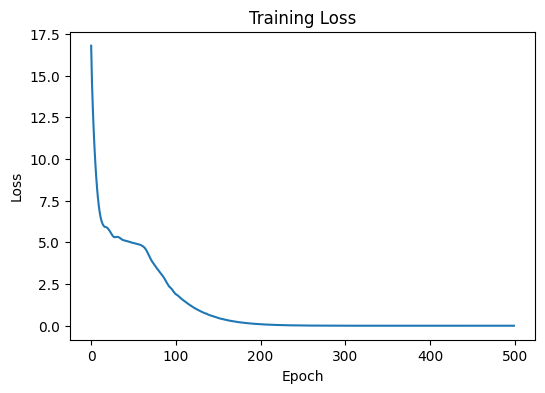

In [713]:
# Hyperparameters
n_epochs = CONFIG['n_epochs']
learning_rate = CONFIG['learning_rate']

# Loss function: Mean Squared Error for regression tasks
loss_fn = nn.MSELoss()

# Optimizer: Adam optimizer with specified learning rate
optimizer = torch.optim.Adam(model_params, lr=learning_rate)

# Store loss values for visualization
loss_history = []

# Initialize dictionary to track gradient norms and hidden state norms over time
gradients_over_time = {
    'Wxh': [],
    'Whh': [],
    'Why': [],
    'hidden_state_norms': []
}

# Training loop
for epoch in range(n_epochs):
    # Generate a new input sequence and its target output
    seq = generate_sequence()
    target = get_target_seq(seq)

    # Initialize hidden state at the start of the sequence
    h = torch.zeros(1, hidden_size)

    outputs = []           # To store model outputs at each time step
    hidden_states = []     # To store hidden states for gradient tracking

    # Process sequence one time step at a time
    for t in range(sequence_length):
        x_t = seq[t].unsqueeze(0)  # Shape: (1, input_size)

        # Compute new hidden state
        h = activation_fn(x_t @ Wxh + h @ Whh + bh)

        # Retain gradients for each hidden state for later inspection
        h.retain_grad()

        # Compute output for the current time step
        y_t = h @ Why + by

        outputs.append(y_t)
        hidden_states.append(h)

    # Concatenate all outputs to compute loss
    outputs = torch.cat(outputs, dim=0)

    # Compute loss between predicted and target sequences
    loss = loss_fn(outputs, target)

    # Zero the gradients from the previous step
    optimizer.zero_grad()

    # Backpropagate to compute gradients
    loss.backward()

    # Optional: Clip gradients to prevent exploding gradients
    max_grad_norm = CONFIG['max_grad_norm']
    if max_grad_norm:
        torch.nn.utils.clip_grad_norm_(model_params, max_norm=max_grad_norm)

    # Track parameter gradient norms for analysis
    gradients_over_time['Wxh'].append(Wxh.grad.norm().item())
    gradients_over_time['Whh'].append(Whh.grad.norm().item())
    gradients_over_time['Why'].append(Why.grad.norm().item())

    # Track hidden state gradient norms at each time step
    hidden_state_grad_norms = [h.grad.norm().item() for h in hidden_states]
    gradients_over_time['hidden_state_norms'].append(hidden_state_grad_norms)

    # Update model parameters
    optimizer.step()

    # Record current loss
    loss_history.append(loss.item())

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}')

# Plot the training loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

The loss has stagnated, indicating that the model is no longer improving with additional training. This could mean it has either converged to a solution or become trapped in a suboptimal state. Let's test its predictions:


In [714]:
batch_size = CONFIG["batch_size"]

# Generate input sequence and corresponding target sequence
sequence = generate_sequence()
target_sequence = get_target_seq(sequence)

# Initialize hidden state
hidden_state = torch.zeros(batch_size, hidden_size)

# Lists to store predictions and hidden states
outputs = []
hidden_states = []

# No need to disable grad for sequence generation and setup
# Only disable gradient calculation during the forward pass
for t in range(sequence_length):
    # Get input at current timestep and add batch dimension
    x_t = sequence[t].unsqueeze(0)  # shape: (1, input_size)

    with torch.no_grad():
        # Compute hidden state: apply activation function to weighted input and previous hidden state
        hidden_state = activation_fn(x_t @ Wxh + hidden_state @ Whh + bh)

        # Compute output (logits or raw scores)
        y_t = hidden_state @ Why + by

    # Store prediction (as scalar)
    outputs.append(y_t.item())

    # Store hidden state (for analysis or visualization later)
    hidden_states.append(hidden_state.numpy())

# Round predictions for easier comparison and convert target to integer list
rounded_outputs = [round(x) for x in outputs]
target_values = target_sequence.view(-1).int().tolist()

rounded_outputs, target_values

([2, 3, 4, 5, 6, 7, 8, 9, 10, 1], [2, 3, 4, 5, 6, 7, 8, 9, 10, 1])

The model has failed to learn the sequence correctly. It begins with accurate predictions but deteriorates further along the sequence. Let's analyze how the hidden states behave throughout the sequence to understand why:


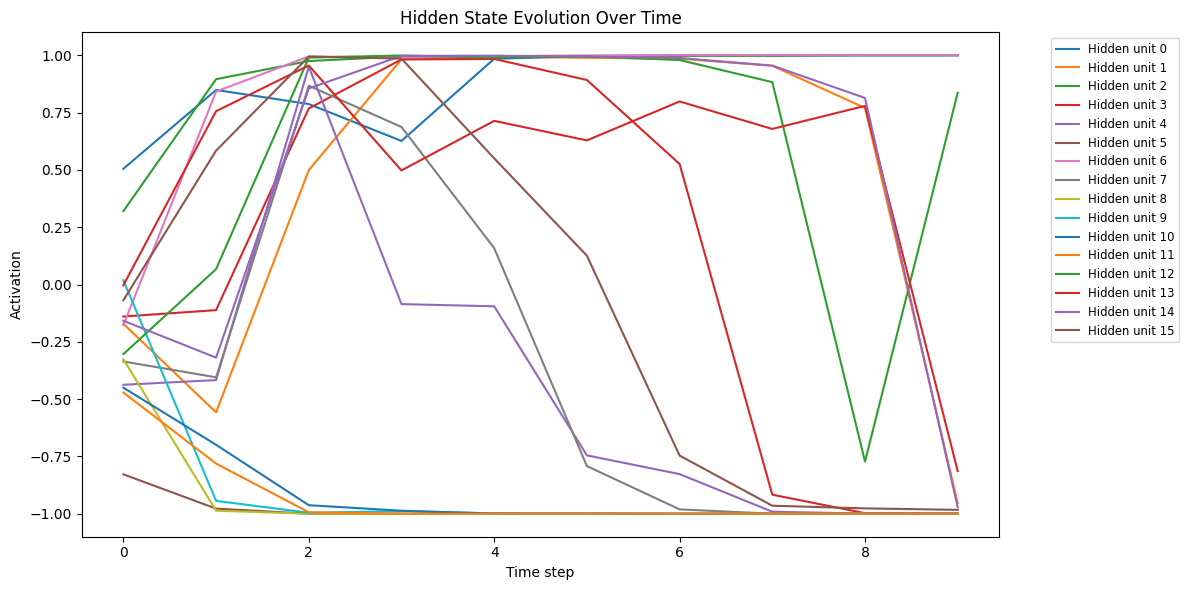

In [715]:
# Convert list of hidden states to a tensor, remove singleton batch dimension, and convert to NumPy array
# hidden_states was a list of numpy arrays; we make it a tensor for easier manipulation
hidden_states = torch.tensor(hidden_states).squeeze(1).numpy()  # shape: (sequence_length, hidden_size)

# Create a new figure for plotting
plt.figure(figsize=(12, 6))

# Plot the activation of each hidden unit over time
for i in range(hidden_size):
    plt.plot(hidden_states[:, i], label=f'Hidden unit {i}')

# Add title and axis labels to the plot
plt.title('Hidden State Evolution Over Time')
plt.xlabel('Time step')
plt.ylabel('Activation')

# Add legend outside the plot area to avoid clutter
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')

# Adjust layout to make room for the legend and labels
plt.tight_layout()

# Display the plot
plt.show()

The graph above reveals that hidden states are converging to the extremes of the tanh function (-1 and 1). At these extremes, the function has a flat surface where gradients approach zero, leading to the **vanishing gradient problem**. This means:

1. No meaningful learning occurs at these points since the gradient is nearly zero
2. We cannot effectively backpropagate the loss through the entire calculation chain
3. The model fails to make the necessary parameter adjustments to minimize the loss

This problem is particularly severe in RNNs because gradients must flow backward through many time steps, and when each step multiplies by a small number (near-zero gradient), the overall gradient diminishes exponentially - preventing the model from learning long-range dependencies.


To gain further insight into the hidden state behavior, let's examine their distribution across all time steps. This visualization can help us understand how the values are concentrated at the extremes of the activation range:

If most values cluster at -1 and 1 (the tanh extremes), this confirms our suspicion of saturation, where gradients effectively become zero. Ideally, we want hidden state values distributed more uniformly across the activation range, where gradients are stronger and learning is more effective.


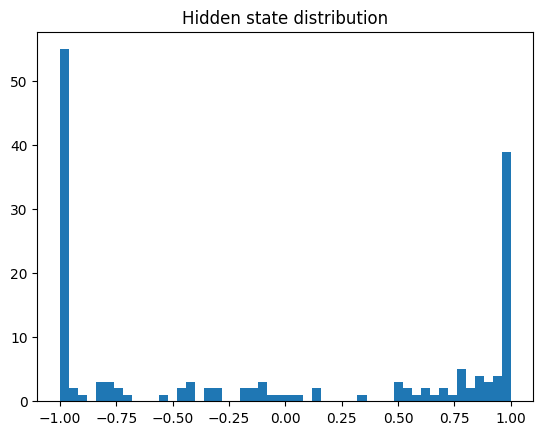

In [716]:
plt.hist(hidden_states.flatten(), bins=50)
plt.title('Hidden state distribution')
plt.show()

Having visualized the hidden states themselves, let's now examine how effectively gradients flow backward through these states during training. This will directly illustrate the vanishing gradient problem we suspect is occurring:

This visualization shows the magnitude (norm) of gradients at each time step during backpropagation. If the gradient norm decreases dramatically as we move backward through time steps, it confirms that earlier parts of the sequence receive very weak learning signals - a hallmark of the vanishing gradient problem.


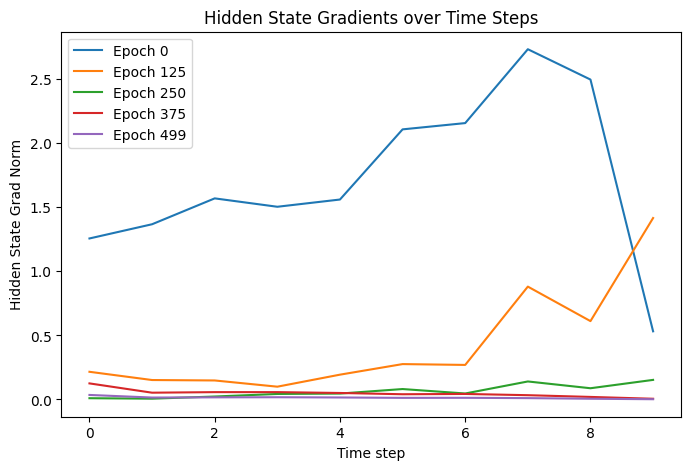

In [717]:
# Determine the total number of epochs recorded in gradients_over_time
total_epochs = len(gradients_over_time['hidden_state_norms'])

# Dynamically select a few representative epochs to plot
# Specifically: the first epoch, an early epoch, middle epoch, late epoch, and the last epoch
epochs_to_plot = [
    0,  # Start of training
    max(1, total_epochs // 4),  # Early training
    max(1, total_epochs // 2),  # Mid training
    max(1, (3 * total_epochs) // 4),  # Late training
    total_epochs - 1  # End of training
]

# Create a new figure for plotting
plt.figure(figsize=(8, 5))

# Plot the gradient norms for the selected epochs
for epoch in epochs_to_plot:
    grad_norms = gradients_over_time['hidden_state_norms'][epoch]  # Gradients of hidden state norms at this epoch
    plt.plot(grad_norms, label=f'Epoch {epoch}')  # Plot gradient norms across time steps

# Add legend and display plots
plt.xlabel('Time step')
plt.ylabel('Hidden State Grad Norm')
plt.title('Hidden State Gradients over Time Steps')
plt.legend()
plt.show()

Notice how the hidden state gradient magnitudes diminish the further back we go in the sequence - a clear visualization of the vanishing gradient problem that's preventing our model from learning long-range dependencies.

This exponential decay of gradients explains why our RNN struggles with the sequence prediction task. Earlier inputs (at the beginning of the sequence) receive minimal gradient updates, essentially making the model "forget" information from those time steps. This is why more advanced architectures like LSTM and GRU were developed - they include mechanisms specifically designed to mitigate this problem.


After examining hidden state gradients across time steps, let's also analyze how the gradients for our weight parameters evolve throughout the training process. This will help us understand how effectively our model parameters are being updated:


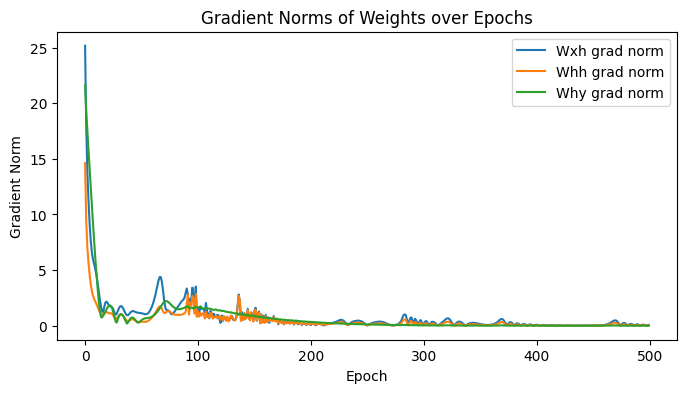

In [718]:
plt.figure(figsize=(8, 4))  # Set figure size
plt.plot(gradients_over_time['Wxh'], label='Wxh grad norm')  # Input-to-hidden weights
plt.plot(gradients_over_time['Whh'], label='Whh grad norm')  # Hidden-to-hidden weights
plt.plot(gradients_over_time['Why'], label='Why grad norm')  # Hidden-to-output weights
plt.xlabel('Epoch')  # X-axis label
plt.ylabel('Gradient Norm')  # Y-axis label
plt.title('Gradient Norms of Weights over Epochs')  # Plot title
plt.legend()  # Add legend
plt.show()  # Display plot

Notice the sharp spikes and sudden drops in the gradient norms — this is a hallmark of unstable training. The model is experiencing both exploding and vanishing gradients simultaneously, and these issues can feed into each other, amplifying instability. Exploding gradients can push activations into saturation, which in turn accelerates vanishing gradients during backpropagation.

## 🚀 Next Steps

I suggest running this notebook again with the following modifications (test each one separately before combining them):

**1. Enable proper weight initialization**
- The current parameter initialization may contribute to early tanh saturation
- Use Xavier initialization for tanh/sigmoid activations
- Use Kaiming initialization for ReLU activations
- This helps constrain initial activations and improve learning

**2. Enable gradient clipping**
- While we're facing vanishing gradients, the occasional gradient explosions visible in our graphs may be problematic
- Set `max_grad_norm` to `1.0` to rescale gradients to a smaller range
- This may help keep values within the responsive region of the tanh activation
- Note: When limiting gradient size, you may need to increase training epochs (since updates become smaller)

**3. Try ReLU as the activation function**
- Unlike tanh, ReLU doesn't constrain values to [-1, 1]
- For our positive-value sequence, this should prevent gradient collapse
- ReLU allows gradients to flow properly through the network
- Note: ReLU can face similar issues (dying ReLUs) with negative values, where activations become zero
